# 🎓 Student Performance Predictor

A complete Google Colab project to predict student performance using machine learning.

Dataset used: `Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv`

In [ ]:
# Step 1: Upload the Dataset
from google.colab import files
uploaded = files.upload()

Saving Student_Performance_Predictor_Dataset.csv to Student_Performance_Predictor_Dataset (1).csv


In [ ]:
# Step 2: Load the Dataset
import pandas as pd
df = pd.read_csv('/content/Student_Performance_Predictor_Dataset.csv')
df.head()

,gender,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,associate degree,standard,none,80,52,46,59.33
1,male,some college,free/reduced,none,87,51,88,75.33
2,male,some college,standard,none,41,50,58,49.67
3,female,associate degree,free/reduced,completed,85,86,89,86.67
4,male,master degree,free/reduced,completed,91,100,45,78.67


In [ ]:
# Step 3: Data Exploration
df.info()
df.describe(include='all')
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       100 non-null    object 
 1   parental_level_of_education  100 non-null    object 
 2   lunch                        100 non-null    object 
 3   test_preparation_course      100 non-null    object 
 4   math_score                   100 non-null    int64  
 5   reading_score                100 non-null    int64  
 6   writing_score                100 non-null    int64  
 7   average_score                100 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 6.4+ KB


Index(['gender', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'average_score'],
      dtype='object')

In [ ]:
# Step 4: Check for Missing Values and Duplicates
print("Missing values:\n", df.isnull().sum())
print("Duplicate entries:", df.duplicated().sum())

Missing values:
 gender                         0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
average_score                  0
dtype: int64
Duplicate entries: 0


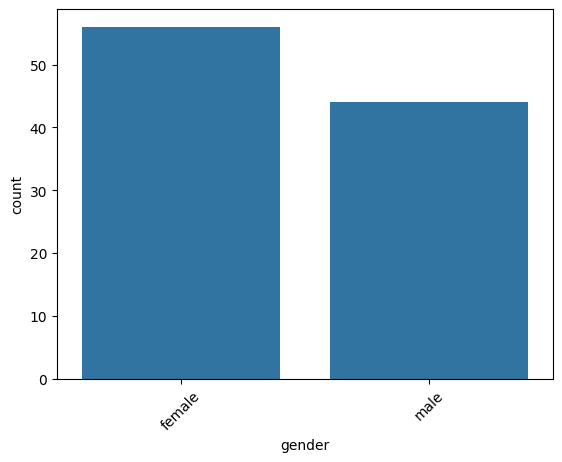

In [ ]:
# Step 5: Visualize a Few Features
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x=df.columns[0])
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Step 6: Identify Target and Features
# Based on the loaded 'Student_Performance_Predictor_Dataset.csv', 'average_score' is a more suitable target.
X = df.drop('average_score', axis=1)
y = df['average_score']

In [ ]:
# Step 7: Convert Categorical Columns to Numerical (if needed)
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category').cat.codes

In [ ]:
# Step 8: One-Hot Encoding (optional if necessary)
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# Step 9: Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Step 10: Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Step 11: Model Building
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42) # Added random_state for reproducibility
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Step 12: Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = model.predict(X_test)

print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test, y_pred):.2f}")

Mean Absolute Error (MAE): 3.27
Mean Squared Error (MSE): 15.61
R-squared (R2 Score): 0.82


In [ ]:
# Step 13-15: Make Predictions and Format Input
# Using example numerical values from the first row of X (after preprocessing)
sample_input_values = X.iloc[0].values.reshape(1, -1) # Get values from the first row of processed X
sample_input = pd.DataFrame(sample_input_values, columns=X.columns)
sample_scaled = scaler.transform(sample_input)
print("Predicted Average Score:", model.predict(sample_scaled)[0])

Predicted Average Score: 68.48480000000002


In [ ]:
# Step 16: Install Gradio for App Deployment
!pip install gradio

In [ ]:
# Step 17: Create a Prediction Function
def predict_grade(*args):
    input_df = pd.DataFrame([args], columns=X.columns)
    input_scaled = scaler.transform(input_df)
    return model.predict(input_scaled)[0]

In [ ]:
# Step 18: Create the Gradio Interface
import gradio as gr
inputs = [gr.Textbox(label=col) for col in X.columns]
gr.Interface(fn=predict_grade, inputs=inputs, outputs="text").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dc00439430f97214db.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
